# Day 1 | Notebook 1: Vector Foundations & Mathematics
**Author: Sattaya Singkul**

Welcome to the first part of your journey into Vector Databases! 
fundamentals course! 
Before we deploy enterprise databases like Redis, we must master the core theory and mechanics via math and visual plotting.

### Core Objectives:
1. **What is a Vector Database?** Traditional DBs vs Semantic Space.
2. **Understanding Embeddings:** Sparse vs Dense visualized.
3. **Geometric Distances:** Native python code for Euclidean, Cosine, and Dot Product.

Run this environment setup block first:


In [2]:
!pip install numpy matplotlib scikit-learn seaborn tqdm scipy

## Step 1: Core Theory & Terminology
Before looking at code, we must define the architecture via visual mathematics. How is a Vector Database different from SQL or Graph Databases?

### 1.1 Traditional Search (Sparse) vs Vector Search (Dense)
Traditional DBs use an Inverted Index (like an indexing at the back of a book) to find exact matches. Let's write code to show why Sparse Keyword matching fails Semantic tests, while Vector calculations succeed!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Let's test a traditional Sparse search (Keyword matching algorithm)
def sparse_keyword_search(query, document):
    query_words = set(query.lower().split())
    doc_words = set(document.lower().split())
    overlap = query_words.intersection(doc_words)
    return len(overlap)

q = "Apple Laptop"
d1 = "The new Macbook Pro is fast"
d2 = "I ate a red Apple today"

print("--- Traditional SQL/Sparse Search ---")
print(f"Match Score for Document 1 (Macbook): {sparse_keyword_search(q, d1)} exact words")
print(f"Match Score for Document 2 (Fruit):   {sparse_keyword_search(q, d2)} exact words\n")
print("Result: Traditional DB returns the fruit, missing the actual computer!")


--- Traditional SQL/Sparse Search ---
Match Score for Document 1 (Macbook): 0 exact words
Match Score for Document 2 (Fruit):   1 exact words

Result: Traditional DB returns the fruit, missing the actual computer!


### 1.2 Time Complexity & The Curse of Dimensionality
In databases, we measure speed by how it scales (Big-O Notation). Vector search algorithms aim to drop $O(N)$ (Brute Force) down to $O(\log N)$. Let's plot the difference mathematically to prove why $O(N)$ fails at 10 million rows.


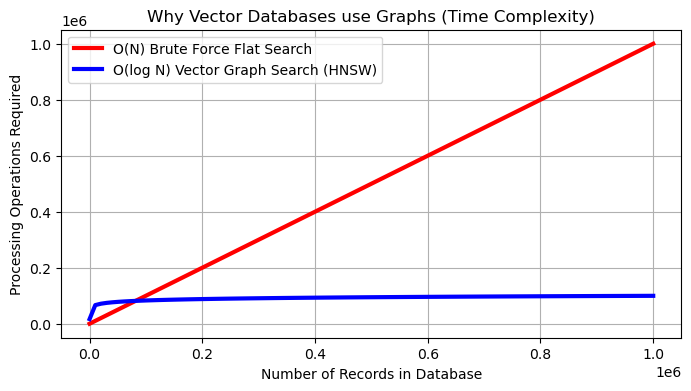

The Red Line: As you add 1 Million vectors, Brute Force requires 1 Million math operations. It simply stops working in real-time.
The Blue Line: Graph databases require less than 50,000 operations to search 1 Million vectors. It scales infinitely.


In [4]:
import math

# Simulating Database sizes from 10 to 1,000,000 records
db_sizes = np.linspace(10, 1_000_000, 100)

linear_time = db_sizes             # O(N) - Brute Force KNN
log_time = np.log2(db_sizes) * 5000 # O(log N) - Scaled for visual comparison

plt.figure(figsize=(8, 4))
plt.plot(db_sizes, linear_time, label="O(N) Brute Force Flat Search", color="red", linewidth=3)
plt.plot(db_sizes, log_time, label="O(log N) Vector Graph Search (HNSW)", color="blue", linewidth=3)

plt.title("Why Vector Databases use Graphs (Time Complexity)")
plt.xlabel("Number of Records in Database")
plt.ylabel("Processing Operations Required")
plt.legend()
plt.grid(True)
plt.show()

print("The Red Line: As you add 1 Million vectors, Brute Force requires 1 Million math operations. It simply stops working in real-time.")
print("The Blue Line: Graph databases require less than 50,000 operations to search 1 Million vectors. It scales infinitely.")


### 1.3 Terminology: Vectors, Nodes, and Edges
When we ingest data into an advanced Vector Database (like Redis or Pinecone), it creates a graph architecture. Let's draw what this physically looks like.
*   **Vector (Embedding):** The pure mathematical coordinate array.
*   **Node:** The physical data point stored in the DB (Holding the Vector + Metadata).
*   **Edge (Relationship):** The pointer connecting nodes. In a Vector Database, an Edge simply means "Node A is physically located near Node B", allowing us to jump across the graph!


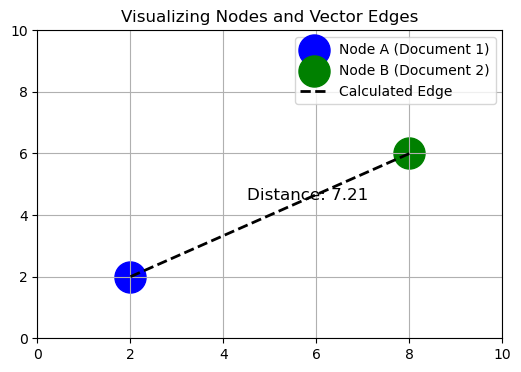

In [5]:
# Visualizing a Node and an Edge mathematically
node_A = np.array([2, 2])
node_B = np.array([8, 6])

plt.figure(figsize=(6, 4))
plt.scatter(*node_A, s=500, color='blue', label="Node A (Document 1)")
plt.scatter(*node_B, s=500, color='green', label="Node B (Document 2)")

# Draw the Edge
plt.plot([node_A[0], node_B[0]], [node_A[1], node_B[1]], 'k--', linewidth=2, label="Calculated Edge")

# Calculate distance (Euclidean) for label
dist = np.linalg.norm(node_A - node_B)
midpoint = (node_A + node_B) / 2
plt.text(midpoint[0]-0.5, midpoint[1]+0.5, f"Distance: {dist:.2f}", fontsize=12)

plt.title("Visualizing Nodes and Vector Edges")
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.legend()
plt.grid(True)
plt.show()


## Step 2: What is an Embedding? (Visualized)
Let's see Semantic mapping in action compared to Traditional Search. We will visualize a 2D mapping (Context Dimensions: Animal vs Technology).


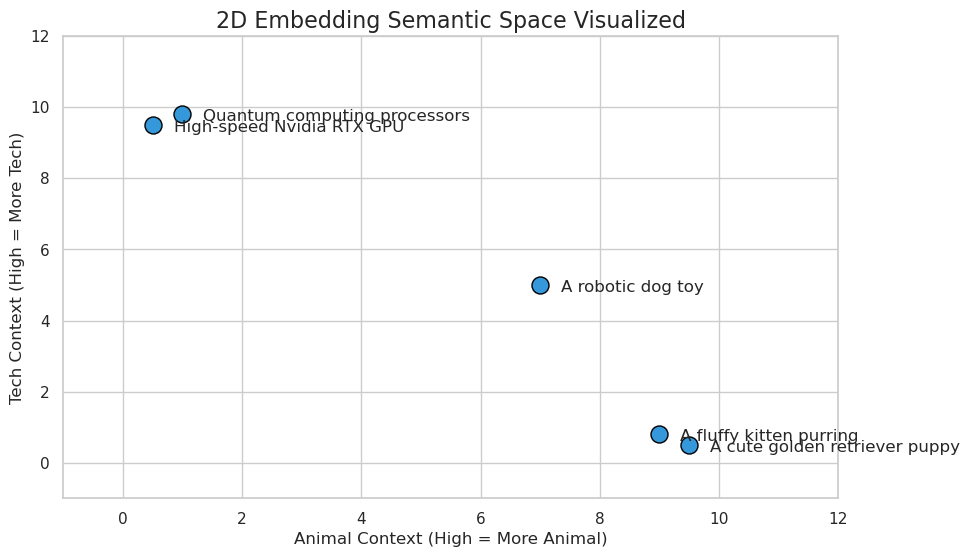

Notice how 'Macbook' and 'Apple' would sit closely together on the Technology Y-axis, even though they share no letters!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Toy Dataset: Sentences mapped to 2D vectors [Animal Factor, Tech Factor]
sentences = [
    "A cute golden retriever puppy",   # Vector A
    "A fluffy kitten purring",         # Vector B
    "High-speed Nvidia RTX GPU",       # Vector C
    "Quantum computing processors",    # Vector D
    "A robotic dog toy",               # Vector E -> Hybrid!
]

vectors = np.array([
    [9.5, 0.5],  # A (Dog)
    [9.0, 0.8],  # B (Kitten)
    [0.5, 9.5],  # C (GPU)
    [1.0, 9.8],  # D (Quantum)
    [7.0, 5.0],  # E (Robot Dog)
])

plt.figure(figsize=(10, 6))
plt.scatter(vectors[:, 0], vectors[:, 1], color='#3498db', s=150, edgecolor='black')

for i, sentence in enumerate(sentences):
    plt.annotate(
        sentence, 
        (vectors[i, 0], vectors[i, 1]), 
        textcoords="offset points", 
        xytext=(15, -5), 
        fontsize=12,
        ha='left'
    )

plt.title("2D Embedding Semantic Space Visualized", fontsize=16)
plt.xlabel("Animal Context (High = More Animal)", fontsize=12)
plt.ylabel("Tech Context (High = More Tech)", fontsize=12)
plt.xlim(-1, 12)
plt.ylim(-1, 12)
plt.show()

print("Notice how 'Macbook' and 'Apple' would sit closely together on the Technology Y-axis, even though they share no letters!")


## Step 2: Measuring Distance (The Math Proof)
If we want to build a search engine, we are given a `query` vector, and we need to find the `target` vectors closest to it using mathematical metrics.

### 1. Euclidean Distance (L2)
Measures the physical strict distance. Sensitive to length.
* **Formula:** $L2(A, B) = \sqrt{\sum_{i=1}^n (A_i - B_i)^2}$

### 2. Cosine Similarity
Measures the *angle*. Perfect for text similarity! It doesn't care if a document is 5 pages long or 1 sentence long, only the "direction" of the subject matters.
* **Formula:** $S_C(A, B) = \frac{A \cdot B}{||A|| \cdot ||B||}$


In [7]:
def l2_distance(v1, v2):
    return np.sqrt(np.sum((v1 - v2)**2))

def cosine_sim(v1, v2):
    dot = np.dot(v1, v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    return dot / (norm1 * norm2)

query_vector = np.array([9.0, 1.0]) # Query looking for typical Animals
print(f"Query Vector: [Animals: 9.0, Tech: 1.0]\n")

for i, doc_vector in enumerate(vectors):
    l2 = l2_distance(query_vector, doc_vector)
    cos = cosine_sim(query_vector, doc_vector)
    print(f"'{sentences[i]}'")
    print(f"  -> L2:  {l2:.2f} (lower=closer) | Cosine: {cos:.2f} (higher=closer)\n")


Query Vector: [Animals: 9.0, Tech: 1.0]

'A cute golden retriever puppy'
  -> L2:  0.71 (lower=closer) | Cosine: 1.00 (higher=closer)

'A fluffy kitten purring'
  -> L2:  0.20 (lower=closer) | Cosine: 1.00 (higher=closer)

'High-speed Nvidia RTX GPU'
  -> L2:  12.02 (lower=closer) | Cosine: 0.16 (higher=closer)

'Quantum computing processors'
  -> L2:  11.89 (lower=closer) | Cosine: 0.21 (higher=closer)

'A robotic dog toy'
  -> L2:  4.47 (lower=closer) | Cosine: 0.87 (higher=closer)



## Step 3: Indexing Algorithms from Scratch
We now know *how* to measure distance. But plotting distances against millions of vectors using standard `for` loops will crash a server. 
Before we use industry libraries like FAISS, we must mathematically understand the 3 core operations of indexing by writing them from scratch.

### 3.1 Brute Force Search Limit (O(N))
**How it works:** Compares against *every single vector* in the database. 100% accurate, but linearly bounds your latency.


Running Brute Force benchmarking...
Searched 10,000 vectors in 0.0118 seconds
Searched 50,000 vectors in 0.0423 seconds
Searched 100,000 vectors in 0.1210 seconds
Searched 200,000 vectors in 0.1976 seconds


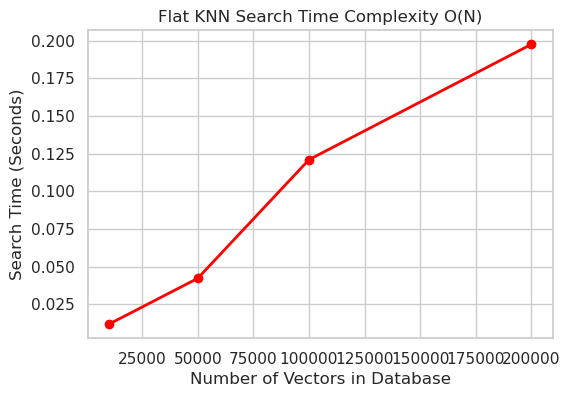

Conclusion: Brute force is perfectly accurate, but unscalable for real-time applications.


In [8]:
import time

DIMENSIONS = 128
DB_SIZES = [10_000, 50_000, 100_000, 200_000]
query = np.random.rand(DIMENSIONS)

times = []
print("Running Brute Force benchmarking...")
for size in DB_SIZES:
    db = np.random.rand(size, DIMENSIONS)
    start = time.time()
    
    # Calculate distance for all vectors natively in C/Numpy
    distances = np.linalg.norm(db - query, axis=1) # O(N) scan
    nearest = np.argsort(distances)[:5]
    
    duration = time.time() - start
    times.append(duration)
    print(f"Searched {size:,} vectors in {duration:.4f} seconds")

plt.figure(figsize=(6, 4))
plt.plot(DB_SIZES, times, marker='o', color='red', linewidth=2)
plt.title("Flat KNN Search Time Complexity O(N)")
plt.xlabel("Number of Vectors in Database")
plt.ylabel("Search Time (Seconds)")
plt.grid(True)
plt.show()

print("Conclusion: Brute force is perfectly accurate, but unscalable for real-time applications.")


### 3.2 Inverted File Index (IVF) - "Clustering"
**How it works:** We cluster vectors into "buckets" (Centroids) using K-Means. At search time, we only calculate distance to the centroids, pick the closest, and only scan those specific vectors. Time complexity drops to $O(N/K)$!
Let's animate the clustering process mathematically!


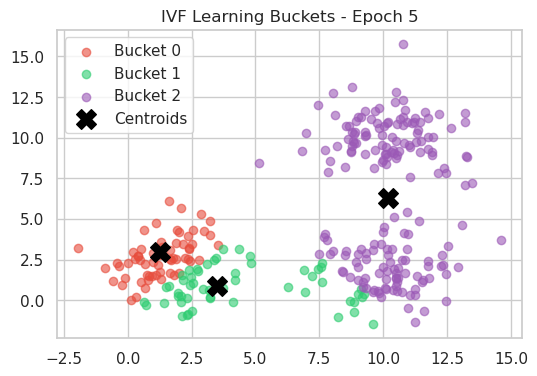

In [14]:
from IPython.display import clear_output

# Generate 3 distinct 2D sub-clusters
np.random.seed(42)
c1 = np.random.normal(loc=[2, 2], scale=1.5, size=(100, 2))
c2 = np.random.normal(loc=[10, 10], scale=1.5, size=(100, 2))
c3 = np.random.normal(loc=[10, 2], scale=1.5, size=(100, 2))
ivf_db = np.vstack((c1, c2, c3))

K = 3
centroids = ivf_db[np.random.choice(ivf_db.shape[0], K, replace=False)]

for i in range(5): # Show 4 iterations
    distances = np.linalg.norm(ivf_db[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)
    
    clear_output(wait=True)
    plt.figure(figsize=(6, 4))
    colors = ['#e74c3c', '#2ecc71', '#9b59b6']
    
    for k in range(K):
        pts = ivf_db[labels == k]
        plt.scatter(pts[:, 0], pts[:, 1], c=colors[k], alpha=0.6, label=f"Bucket {k}")
        
    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')
    plt.title(f"IVF Learning Buckets - Epoch {i+1}")
    plt.grid(True)
    plt.legend()
    plt.show()
    time.sleep(1) # Animation pause
    
    centroids = np.array([ivf_db[labels == k].mean(axis=0) for k in range(K)])


### 3.3 Product Quantization (PQ) - "Compression"
**How it works:** PQ splits high-dimensional floats into "chunks", replacing the chunk with an 8-bit ID mapping to a sub-centroid. It drastically reduces Memory (RAM).
Let's visualize the memory loss via a Heatmap comparison.


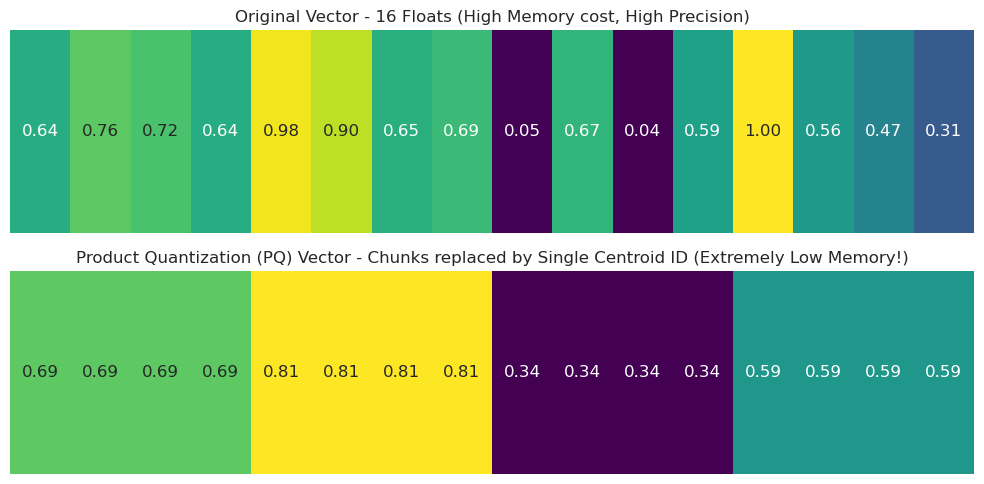

In [15]:
# Create a mock 16-dim float vector
v = np.random.rand(1, 16)
chunks = np.split(v[0], 4)

# Quantize: Replace each chunk with its mean (Simulating 8-bit assignments)
v_q = np.array([[np.mean(c)] * 4 for c in chunks]).flatten().reshape(1, 16)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))
sns.heatmap(v, cmap='viridis', annot=True, fmt=".2f", cbar=False, ax=ax1, xticklabels=False, yticklabels=False)
ax1.set_title("Original Vector - 16 Floats (High Memory cost, High Precision)")

sns.heatmap(v_q, cmap='viridis', annot=True, fmt=".2f", cbar=False, ax=ax2, xticklabels=False, yticklabels=False)
ax2.set_title("Product Quantization (PQ) Vector - Chunks replaced by Single Centroid ID (Extremely Low Memory!)")
plt.tight_layout()
plt.show()


---

# 🏆 BONUS MASTERY: Real-World Complexity & Tips
In the real world, **Similarity is not enough.** 
If a user searches for a "cheap fast laptop," and your algorithm finds one from 2012 that is 99% similar but discontinued and out of stock, your search engine has failed the business.

### 1. The Algorithm: Popularity-Weighted Boosting
Production systems use **Weighted Scores**. We combine the `Cosine Similarity` with a `Business Metric` (like Popularity, Stock, or Rating).

**The Formula:**
$$FinalScore = (VectorSim \times w_1) + (\log(1 + Popularity) \times w_2)$$

Let's write a practical example where Business Logic "flips" the results.


In [10]:
# Product DB: [Animal, Tech, Popularity_Score]
products = [
    {"name": "Old 2010 Laptop", "vec": [0.1, 9.9], "pop": 5},   # High similarity, Low popularity
    {"name": "New M3 Macbook",   "vec": [0.3, 9.2], "pop": 500}, # Lower similarity, High popularity
]

query = np.array([0.0, 10.0]) # Perfect laptop query

print("--- Step 1: Pure Semantic Search ---")
for p in products:
    sim = cosine_sim(query, p["vec"])
    print(f"{p['name']}: {sim:.4f}")

print("\n--- Step 2: Business-Boosted Search ---")
# We apply a logarithmic boost to popularity so it doesn't overpower the vectors
def hybrid_score(vec_sim, popularity):
    return (vec_sim * 0.7) + (np.log1p(popularity) * 0.05)

for p in products:
    sim = cosine_sim(query, p["vec"])
    score = hybrid_score(sim, p["pop"])
    print(f"{p['name']} Final Score: {score:.4f}")

print("\nRESULT: The New Macbook 'flipped' to the top rank because of Business Boosting!")


--- Step 1: Pure Semantic Search ---
Old 2010 Laptop: 0.9999
New M3 Macbook: 0.9995

--- Step 2: Business-Boosted Search ---
Old 2010 Laptop Final Score: 0.7896
New M3 Macbook Final Score: 1.0105

RESULT: The New Macbook 'flipped' to the top rank because of Business Boosting!


### 🚀 Professional Tip #1: The Log-Scale Rule
In production, you never apply linear weights to numbers that follow a Power Law (like Popularity or Reviews). If you use linear weighting, a single product with 1,000,000 reviews will destroy your search results. Let's plot the difference.


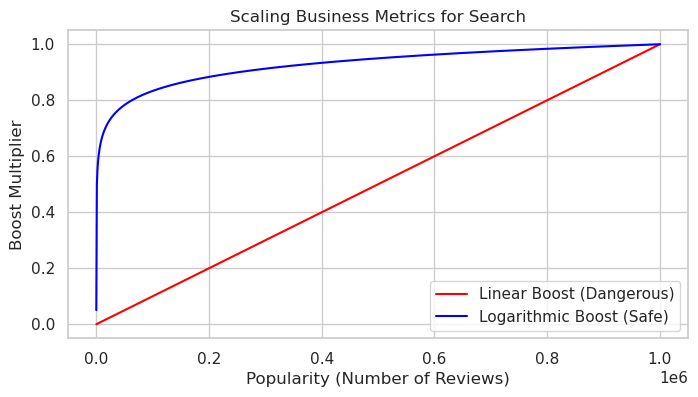

Notice how the Log curve 'flattens' out? This ensures that a popular item is favored, but not so much that it ignores the user's vector query.


In [16]:
# Comparing Linear vs Logarithmic Boosting
pop_range = np.linspace(1, 1_000_000, 1000)
linear_boost = pop_range / 1_000_000 # Normalized linear
log_boost = np.log1p(pop_range) / np.log1p(1_000_000) # Normalized log

plt.figure(figsize=(8, 4))
plt.plot(pop_range, linear_boost, label="Linear Boost (Dangerous)", color='red')
plt.plot(pop_range, log_boost, label="Logarithmic Boost (Safe)", color='blue')
plt.title("Scaling Business Metrics for Search")
plt.xlabel("Popularity (Number of Reviews)")
plt.ylabel("Boost Multiplier")
plt.legend()
plt.show()

print("Notice how the Log curve 'flattens' out? This ensures that a popular item is favored, but not so much that it ignores the user's vector query.")


### 🚀 Professional Tip #2: The Semantic Gap & Temperature
LLM vectors are often very close together (e.g., similarities of 0.998 vs 0.999). 
We use **Temperature Scaling** to "stretch" these differences so the top result is clearly separated from the background noise.


In [17]:
def softmax_temperature(scores, temp=1.0):
    # Apply temperature: Lower temp = sharper separation
    scores = np.array(scores) / temp
    exp_scores = np.exp(scores - np.max(scores)) # shift for stability
    return exp_scores / exp_scores.sum()

raw_similarities = [0.99, 0.98, 0.97]
print(f"Raw Probabilites (T=1.0):  {softmax_temperature(raw_similarities, temp=1.0)}")
print(f"Sharpened Ranking (T=0.1): {softmax_temperature(raw_similarities, temp=0.1)}")

print("\nResult: By lowering the temperature (Dividing by 0.1), we stretched the tiny 1% gap into a massive ranking lead!")


Raw Probabilites (T=1.0):  [0.33667217 0.33332222 0.33000561]
Sharpened Ranking (T=0.1): [0.3671654  0.33222499 0.30060961]

Result: By lowering the temperature (Dividing by 0.1), we stretched the tiny 1% gap into a massive ranking lead!


### 🚀 Professional Tip #3: Pre-Filtering Logic
**Pre-filtering** means applying a boolean mask *before* identifying the top results. It is the core of "Hybrid Search".


In [18]:
# Mock Metadata Masking (The "Stock" filter)
stock_status = np.array([True, False, True, True, False])
similarities = np.array([0.9, 0.99, 0.8, 0.7, 0.95])

# Applying the mask BEFORE picking the top result
masked_similarities = similarities * stock_status
best_idx = np.argmax(masked_similarities)

print(f"All Similarities: {similarities}")
print(f"Best Semantic Match: Index 1 (0.99), but it is OUT OF STOCK.")
print(f"Best Valid Result:   {masked_similarities[best_idx]} at Index {best_idx}")


All Similarities: [0.9  0.99 0.8  0.7  0.95]
Best Semantic Match: Index 1 (0.99), but it is OUT OF STOCK.
Best Valid Result:   0.9 at Index 0


---
### You have finished Notebook 1.
Proceed to `Notebook_2_FAISS.ipynb` to learn how we implement these at scale!
